## Find local max

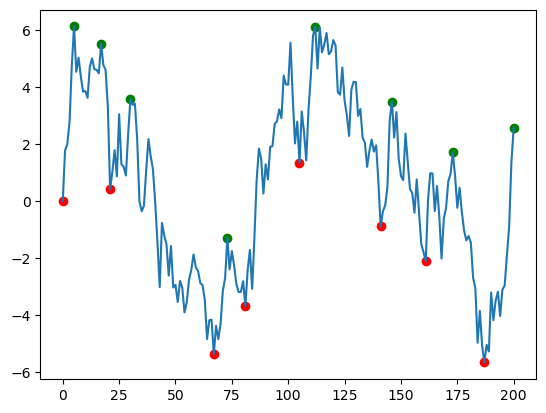

In [1]:
#https://stackoverflow.com/questions/48023982/pandas-finding-local-max-and-min
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.signal import argrelextrema

def apply_gaussian(sig, filter_size=20):
    # sig: 1D signal
    pad_size = filter_size
    sig_pad = np.pad(sig, pad_size, mode='mean', stat_length=pad_size)
# pad with mean
    win = signal.windows.hann(filter_size)
    return signal.convolve(sig_pad, win,
mode='same')[pad_size:len(sig_pad)-pad_size] / sum(win)

# Generate a noisy AR(1) sample

np.random.seed(0)
rs = np.random.randn(200)
xs = [0]
for r in rs:
    xs.append(xs[-1] * 0.9 + r)
#xs = apply_gaussian(xs)
df = pd.DataFrame(xs, columns=['data'])

n = 10  # number of points to be checked before and after

# Find local peaks

df['min'] = df.iloc[argrelextrema(df.data.values, np.less_equal,
                    order=n)[0]]['data']
df['max'] = df.iloc[argrelextrema(df.data.values, np.greater_equal,
                    order=n)[0]]['data']

# Plot results

plt.scatter(df.index, df['min'], c='r')
plt.scatter(df.index, df['max'], c='g')
plt.plot(df.index, df['data'])
plt.show()

/tmp/ipykernel_13375/1745112875.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


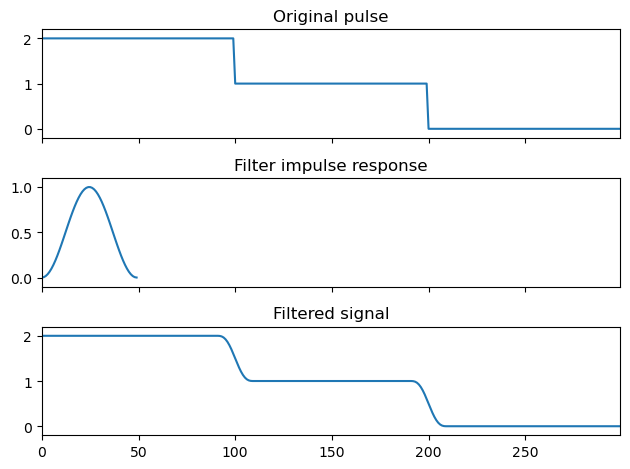

In [2]:
# Gaussian smoothing with mean padding.
# scipy docs - signal convolve

import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

sig = np.repeat([2., 1., 0.], 100)
win = signal.windows.hann(50)
#filtered = signal.convolve(sig, win, mode='same') / sum(win)
filtered = apply_gaussian(sig)

fig, (ax_orig, ax_win, ax_filt) = plt.subplots(3, 1, sharex=True)

ax_orig.plot(sig)
ax_orig.set_title('Original pulse')
ax_orig.margins(0, 0.1)

ax_win.plot(win)
ax_win.set_title('Filter impulse response')
ax_win.margins(0, 0.1)

ax_filt.plot(filtered)
ax_filt.set_title('Filtered signal')
ax_filt.margins(0, 0.1)

fig.tight_layout()
fig.show()

## Load real signal

High temperature - distribution closer to linear multiplication. Temperature close to 0 - almost argmax.

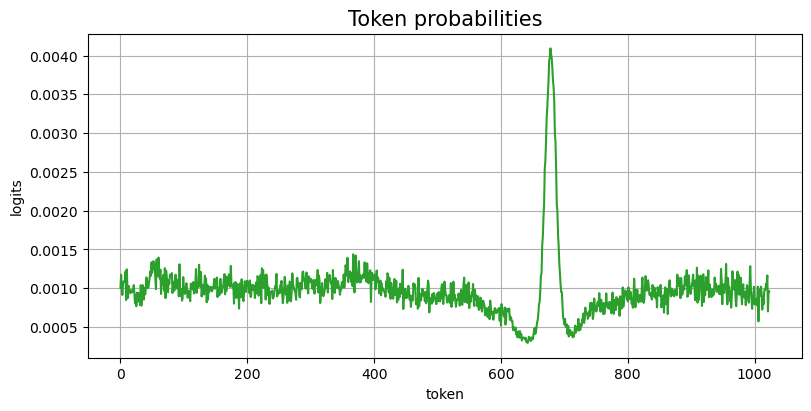

In [8]:
def plot(ax, episode_i=0, crop_size=700):
    with open(f"data/prediction/tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
        decoded_str = str(np.load(f))
        scores = np.load(f) # (12, 1, 1024)
    
    # prediction: start_y start_x start_z r0 r1 r2 end_y end_x end_z r0 r1 r2
    token_pos = 0
    scores = scores[token_pos, 0]
    x = np.arange(len(scores))

    def softmax(x):
        T = 10
        x = np.exp(x / T)
        return x / np.sum(x)

    scores = softmax(scores)

    # plot
    ax.set_title('Token probabilities',fontsize=15)
    ax.plot(x, scores, linestyle='-', color='tab:green')
    ax.grid(True)
    ax.set_xlabel('token',  fontsize=10)
    ax.set_ylabel('logits',  fontsize=10)

fig, axs = plt.subplots(1, 1, layout='constrained', figsize=(8,4))
plot(axs)

In [7]:
# find local extrema
n = 20  # number of points to be checked before and after
argrelextrema(scores, np.greater_equal, order=n)[0]

array([  10,   60,   93,  124,  174,  223,  246,  288,  311,  367,  445,
        470,  511,  542,  678,  755,  828,  909,  955,  993, 1020])